In [1]:
import warnings
warnings.simplefilter(action = "ignore", category = RuntimeWarning)

In [ ]:
import math
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

In [3]:
root_a = "/kaggle/input/sepsis-physionet/sepsis_physionet/training_setA/training"
root_b = "/kaggle/input/sepsis-physionet/sepsis_physionet/training_setB/training_setB"

In [4]:
def create_df(root):
    all_files = glob.glob(os.path.join(root, "*.psv"))
    arr_patients = []
    for file in all_files:
        df = pd.read_csv(file, sep='|')
        df.insert(0, 'id', os.path.basename(file).replace(".psv", ""))
        arr_patients.append(df)
    patients_df = pd.concat(arr_patients, ignore_index=True)
    return patients_df

In [5]:
pd.set_option('display.max_columns', None)

In [6]:
df_a = create_df(root_a)

In [9]:
display(df_a)

,id,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,BaseExcess,HCO3,FiO2,pH,PaCO2,SaO2,AST,BUN,Alkalinephos,Calcium,Chloride,Creatinine,Bilirubin_direct,Glucose,Lactate,Magnesium,Phosphate,Potassium,Bilirubin_total,TroponinI,Hct,Hgb,PTT,WBC,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel
0,p017072,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,68.54,0,NaN,NaN,-0.02,1,0
1,p017072,65.0,100.0,NaN,NaN,72.0,NaN,16.5,NaN,NaN,NaN,0.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,68.54,0,NaN,NaN,-0.02,2,0
2,p017072,78.0,100.0,NaN,NaN,42.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,68.54,0,NaN,NaN,-0.02,3,0
3,p017072,73.0,100.0,NaN,NaN,NaN,NaN,17.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,68.54,0,NaN,NaN,-0.02,4,0
4,p017072,70.0,100.0,NaN,129.0,74.0,69.0,14.0,NaN,NaN,26.0,0.4,NaN,NaN,NaN,NaN,23.0,NaN,9.6,104.0,0.8,NaN,161.0,NaN,1.6,2.1,3.2,NaN,NaN,29.7,9.5,30.6,11.3,NaN,330.0,68.54,0,NaN,NaN,-0.02,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
790210,p016023,93.5,99.0,36.11,80.0,63.0,50.5,9.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45.96,1,NaN,NaN,-6.15,44,0
790211,p016023,85.0,100.0,NaN,84.0,64.0,49.0,10.0,NaN,NaN,NaN,0.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45.96,1,NaN,NaN,-6.15,45,0
790212,p016023,86.0,99.5,NaN,84.0,64.0,50.0,11.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45.96,1,NaN,NaN,-6.15,46,0
790213,p016023,87.0,100.0,36.11,88.0,67.0,52.0,10.5,NaN,NaN,NaN,0.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45.96,1,NaN,NaN,-6.15,47,0


In [7]:
df_a.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 790215 entries, 0 to 790214
Data columns (total 42 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                790215 non-null  object 
 1   HR                729026 non-null  float64
 2   O2Sat             695136 non-null  float64
 3   Temp              266901 non-null  float64
 4   SBP               670014 non-null  float64
 5   MAP               709357 non-null  float64
 6   DBP               409918 non-null  float64
 7   Resp              712957 non-null  float64
 8   EtCO2             0 non-null       float64
 9   BaseExcess        82381 non-null   float64
 10  HCO3              63617 non-null   float64
 11  FiO2              112155 non-null  float64
 12  pH                90615 non-null   float64
 13  PaCO2             69288 non-null   float64
 14  SaO2              39160 non-null   float64
 15  AST               11820 non-null   float64
 16  BUN               64

In [9]:
df_b = create_df(root_b)

In [10]:
display(df_b)

,id,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,BaseExcess,HCO3,FiO2,pH,PaCO2,SaO2,AST,BUN,Alkalinephos,Calcium,Chloride,Creatinine,Bilirubin_direct,Glucose,Lactate,Magnesium,Phosphate,Potassium,Bilirubin_total,TroponinI,Hct,Hgb,PTT,WBC,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel
0,p101097,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,63,1,NaN,NaN,-31.63,1,0
1,p101097,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,63,1,NaN,NaN,-31.63,2,0
2,p101097,90.0,100.0,36.6,105.0,75.0,52.0,17.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,63,1,NaN,NaN,-31.63,3,0
3,p101097,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,63,1,NaN,NaN,-31.63,4,0
4,p101097,77.0,100.0,NaN,118.0,83.0,58.0,18.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,63,1,NaN,NaN,-31.63,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
761990,p113911,83.0,99.0,NaN,121.0,77.0,54.0,22.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,88,0,1.0,0.0,-2.93,22,0
761991,p113911,80.0,92.0,NaN,102.0,73.0,51.0,24.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,88,0,1.0,0.0,-2.93,23,0
761992,p113911,95.0,97.0,36.7,128.5,83.0,58.5,25.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,163.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,88,0,1.0,0.0,-2.93,24,0
761993,p113911,104.0,99.0,NaN,127.0,85.0,59.0,24.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,88,0,1.0,0.0,-2.93,25,0


In [11]:
df_b.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 761995 entries, 0 to 761994
Data columns (total 42 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                761995 non-null  object 
 1   HR                669785 non-null  float64
 2   O2Sat             654338 non-null  float64
 3   Temp              258325 non-null  float64
 4   SBP               655931 non-null  float64
 5   MAP               649583 non-null  float64
 6   DBP               655738 non-null  float64
 7   Resp              600918 non-null  float64
 8   EtCO2             57636 non-null   float64
 9   BaseExcess        1764 non-null    float64
 10  HCO3              1411 non-null    float64
 11  FiO2              17210 non-null   float64
 12  pH                16958 non-null   float64
 13  PaCO2             17013 non-null   float64
 14  SaO2              14401 non-null   float64
 15  AST               13363 non-null   float64
 16  BUN               42

In [12]:
df = pd.concat([df_a, df_b])

In [13]:
display(df)

,id,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,BaseExcess,HCO3,FiO2,pH,PaCO2,SaO2,AST,BUN,Alkalinephos,Calcium,Chloride,Creatinine,Bilirubin_direct,Glucose,Lactate,Magnesium,Phosphate,Potassium,Bilirubin_total,TroponinI,Hct,Hgb,PTT,WBC,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel
0,p017072,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,68.54,0,NaN,NaN,-0.02,1,0
1,p017072,65.0,100.0,NaN,NaN,72.0,NaN,16.5,NaN,NaN,NaN,0.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,68.54,0,NaN,NaN,-0.02,2,0
2,p017072,78.0,100.0,NaN,NaN,42.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,68.54,0,NaN,NaN,-0.02,3,0
3,p017072,73.0,100.0,NaN,NaN,NaN,NaN,17.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,68.54,0,NaN,NaN,-0.02,4,0
4,p017072,70.0,100.0,NaN,129.0,74.0,69.0,14.0,NaN,NaN,26.0,0.4,NaN,NaN,NaN,NaN,23.0,NaN,9.6,104.0,0.8,NaN,161.0,NaN,1.6,2.1,3.2,NaN,NaN,29.7,9.5,30.6,11.3,NaN,330.0,68.54,0,NaN,NaN,-0.02,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
761990,p113911,83.0,99.0,NaN,121.0,77.0,54.0,22.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,88.00,0,1.0,0.0,-2.93,22,0
761991,p113911,80.0,92.0,NaN,102.0,73.0,51.0,24.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,88.00,0,1.0,0.0,-2.93,23,0
761992,p113911,95.0,97.0,36.7,128.5,83.0,58.5,25.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,163.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,88.00,0,1.0,0.0,-2.93,24,0
761993,p113911,104.0,99.0,NaN,127.0,85.0,59.0,24.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,88.00,0,1.0,0.0,-2.93,25,0


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1552210 entries, 0 to 761994
Data columns (total 42 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   id                1552210 non-null  object 
 1   HR                1398811 non-null  float64
 2   O2Sat             1349474 non-null  float64
 3   Temp              525226 non-null   float64
 4   SBP               1325945 non-null  float64
 5   MAP               1358940 non-null  float64
 6   DBP               1065656 non-null  float64
 7   Resp              1313875 non-null  float64
 8   EtCO2             57636 non-null    float64
 9   BaseExcess        84145 non-null    float64
 10  HCO3              65028 non-null    float64
 11  FiO2              129365 non-null   float64
 12  pH                107573 non-null   float64
 13  PaCO2             86301 non-null    float64
 14  SaO2              53561 non-null    float64
 15  AST               25183 non-null    float64
 16  BUN   

## Diagrams

In [15]:
sns.set_theme(style="whitegrid", palette="rocket")

In [16]:
patient_status = df.groupby('id')['SepsisLabel'].max()

In [17]:
patient_status.head(20)

id
p000001    0
p000002    0
p000003    0
p000004    0
p000005    0
p000006    0
p000007    0
p000008    0
p000009    1
p000010    0
p000011    1
p000012    0
p000013    0
p000014    0
p000015    1
p000016    0
p000017    0
p000018    1
p000019    0
p000020    0
Name: SepsisLabel, dtype: int64

In [18]:
septic_ids = patient_status[patient_status == 1].index
non_septic_ids = patient_status[patient_status == 0].index
df_septic = df[df["id"].isin(septic_ids)]
df_nonseptic = df[df["id"].isin(non_septic_ids)]

## Mean number of recorded hours

In [20]:
hours_per_patient = df.groupby("id").size()

In [46]:
hours_per_patient

id
p000001    54
p000002    23
p000003    48
p000004    29
p000005    48
           ..
p119996    48
p119997    25
p119998    49
p119999    20
p120000    35
Length: 40336, dtype: int64

In [21]:
hours_per_patient.describe()

count    40336.000000
mean        38.482001
std         22.795923
min          8.000000
25%         24.000000
50%         38.000000
75%         47.000000
max        336.000000
dtype: float64

In [50]:
hours_per_patient_septic = hours_per_patient[hours_per_patient.index.isin(septic_ids)]
hours_per_patient_nonseptic = hours_per_patient[hours_per_patient.index.isin(non_septic_ids)]

In [52]:
hours_per_patient_septic.describe()

count    2932.000000
mean       58.802865
std        59.184830
min         8.000000
25%        15.000000
50%        37.500000
75%        81.000000
max       336.000000
dtype: float64

In [53]:
hours_per_patient_nonseptic.describe()

count    37404.000000
mean        36.889103
std         15.842660
min          8.000000
25%         24.000000
50%         39.000000
75%         46.000000
max        336.000000
dtype: float64

In [59]:
median = hours_per_patient.median()

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


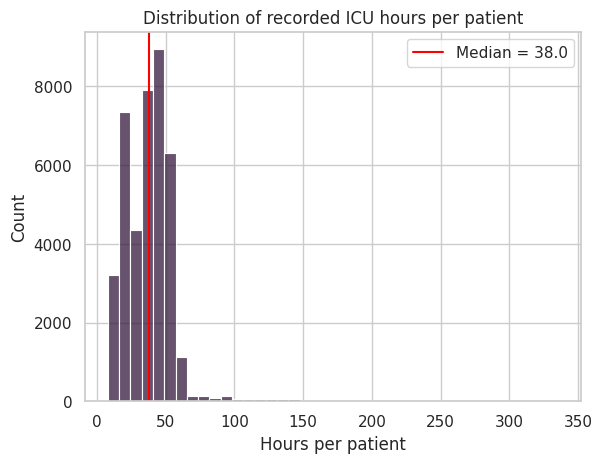

In [60]:
sns.histplot(hours_per_patient, bins = 40)
plt.axvline(median, color="red", label=f"Median = {median:.1f}")
plt.legend()
plt.xlabel("Hours per patient")
plt.ylabel("Count")
plt.title("Distribution of recorded ICU hours per patient")
plt.show()

## Sepsis vs Non-sepsis patients

In [26]:
sepsis_patients = (patient_status == 1).sum()
nonsepsis_patients = (patient_status == 0).sum()

In [27]:
print(f"Patients with sepsis: {sepsis_patients}, patients with no sepsis: {nonsepsis_patients}")

Patients with sepsis: 2932, patients with no sepsis: 37404


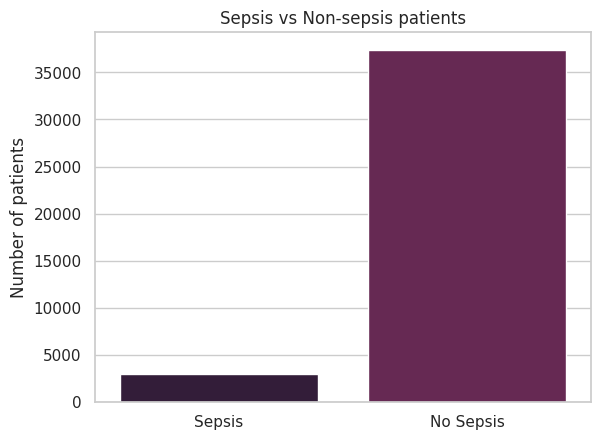

In [28]:
sns.barplot(x=["Sepsis", "No Sepsis"], y=[sepsis_patients, nonsepsis_patients], order=["Sepsis", "No Sepsis"])
plt.title("Sepsis vs Non-sepsis patients")
plt.ylabel("Number of patients")
plt.show()

## Median time after arrival at the emergency room when sepsis is detected

In [29]:
sepsis_events = df[df["SepsisLabel"] == 1]
first_sepsis_hour = sepsis_events.groupby("id")["ICULOS"].min()

In [30]:
first_sepsis_hour.describe()

count    2932.000000
mean       50.896317
std        59.363675
min         1.000000
25%         7.000000
50%        29.000000
75%        73.000000
max       331.000000
Name: ICULOS, dtype: float64

In [31]:
median = first_sepsis_hour.median()

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


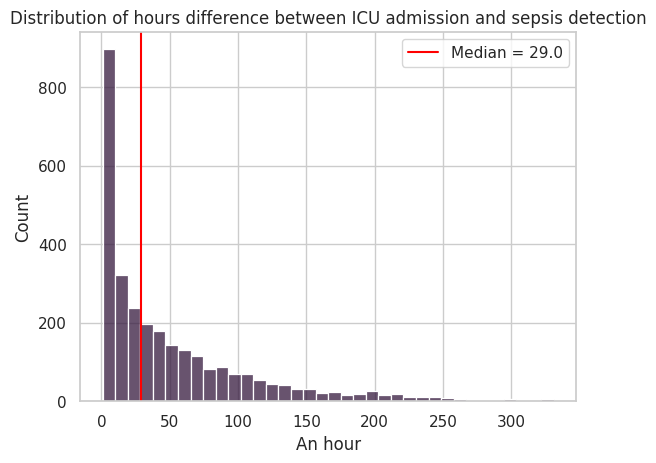

In [32]:
sns.histplot(first_sepsis_hour)
plt.axvline(median, color="red", label=f"Median = {median:.1f}")
plt.legend()
plt.xlabel("An hour")
plt.ylabel("Count")
plt.title("Distribution of hours difference between ICU admission and sepsis detection")
plt.show()

## Missing values

In [33]:
missing_values = df.isnull().mean() * 100
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)
missing_values

Bilirubin_direct    99.807371
Fibrinogen          99.340167
TroponinI           99.047745
Bilirubin_total     98.509158
Alkalinephos        98.393194
AST                 98.377604
Lactate             97.329872
PTT                 97.055875
SaO2                96.549372
EtCO2               96.286843
Phosphate           95.986303
HCO3                95.810618
Chloride            95.460279
BaseExcess          94.579020
PaCO2               94.440121
Calcium             94.116067
Platelets           94.059502
Creatinine          93.904433
Magnesium           93.689578
WBC                 93.593199
BUN                 93.134434
pH                  93.069688
Hgb                 92.617558
FiO2                91.665754
Hct                 91.145979
Potassium           90.689082
Glucose             82.894325
Temp                66.162697
Unit2               39.425078
Unit1               39.425078
DBP                 31.345887
Resp                15.354559
SBP                 14.576958
O2Sat     

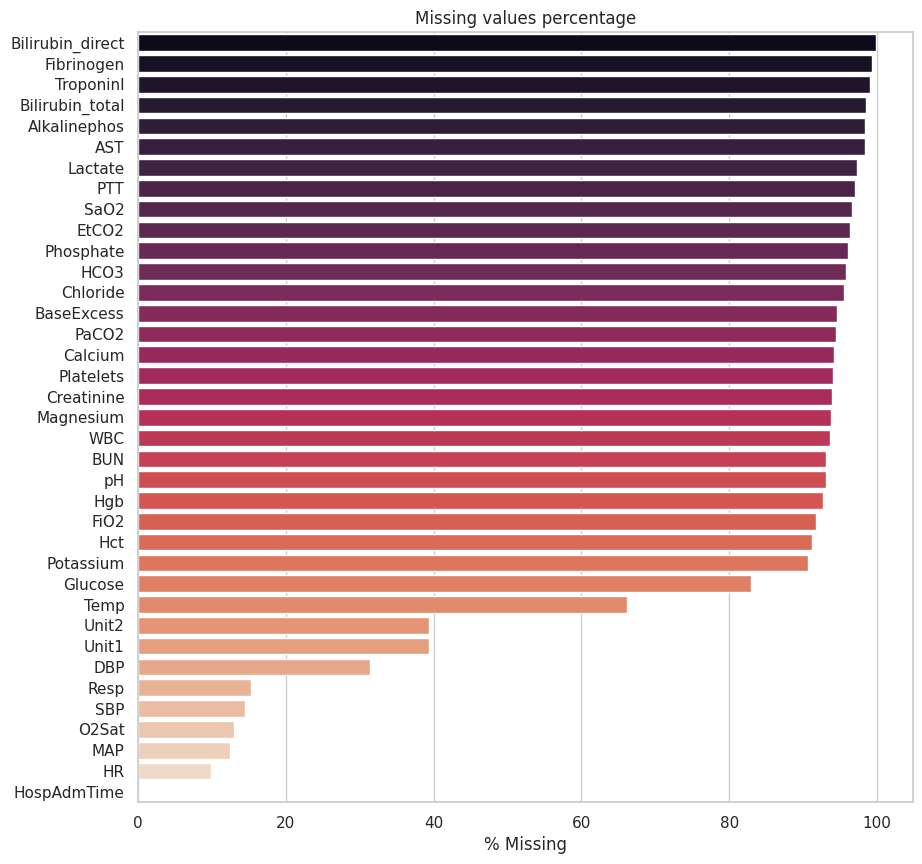

In [34]:
plt.figure(figsize=(10, 10))
sns.barplot(x=missing_values.values,
            y=missing_values.index,
            palette="rocket")
plt.title("Missing values percentage")
plt.xlabel("% Missing")
plt.show()

## Percentage of features presented in sepsis/non-sepsis patients

In [19]:
septic_has_feature = df_septic.groupby("id").apply(lambda x: x.notna().any())
non_has_feature = df_nonseptic.groupby("id").apply(lambda x: x.notna().any())

/tmp/ipykernel_47/3942657855.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  septic_has_feature = df_septic.groupby("id").apply(lambda x: x.notna().any())
/tmp/ipykernel_47/3942657855.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  non_has_feature = df_nonseptic.groupby("id").apply(lambda x: x.notna().any())


In [20]:
septic_percentage = septic_has_feature.mean() * 100
nonseptic_percentage = non_has_feature.mean() * 100

In [22]:
feature_diff = (septic_percentage - nonseptic_percentage).sort_values(ascending=False)
feature_diff

Lactate             33.502509
FiO2                33.192936
PaCO2               31.840865
pH                  31.212400
BaseExcess          22.133161
Alkalinephos        21.581466
AST                 21.457339
Bilirubin_total     21.307393
SaO2                20.252534
PTT                 17.172978
Chloride            12.492193
Phosphate           12.334634
EtCO2               10.785008
HCO3                 9.946697
Fibrinogen           9.445353
Bilirubin_direct     6.270163
Calcium              4.600755
Magnesium            2.811144
DBP                  1.644107
MAP                  0.278045
TroponinI            0.195728
HR                   0.013368
HospAdmTime          0.002674
Age                  0.000000
Gender               0.000000
ICULOS               0.000000
id                   0.000000
SepsisLabel          0.000000
O2Sat               -0.025437
Glucose             -0.152664
Potassium           -0.304864
Resp                -0.325100
Temp                -0.528020
Hct       

In [23]:
feature_diff = feature_diff[feature_diff > 10]

In [24]:
feature_diff

Lactate            33.502509
FiO2               33.192936
PaCO2              31.840865
pH                 31.212400
BaseExcess         22.133161
Alkalinephos       21.581466
AST                21.457339
Bilirubin_total    21.307393
SaO2               20.252534
PTT                17.172978
Chloride           12.492193
Phosphate          12.334634
EtCO2              10.785008
dtype: float64

In [25]:
first_sepsis_time = df[df['SepsisLabel'] == 1].groupby('id')['ICULOS'].min()

In [26]:
first_sepsis_time

id
p000009    249
p000011     26
p000015      6
p000018    126
p000022     14
          ... 
p119888      3
p119910     43
p119917     61
p119938    108
p119959     32
Name: ICULOS, Length: 2932, dtype: int64

In [33]:
top_features = feature_diff.index.tolist()


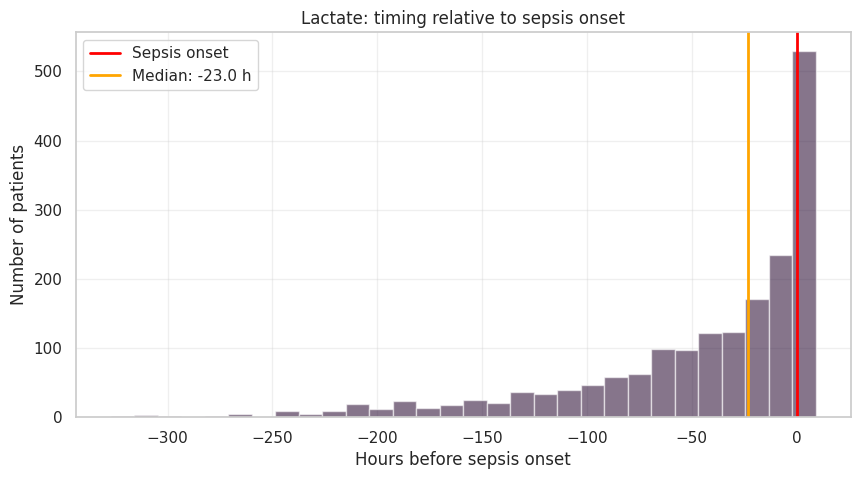

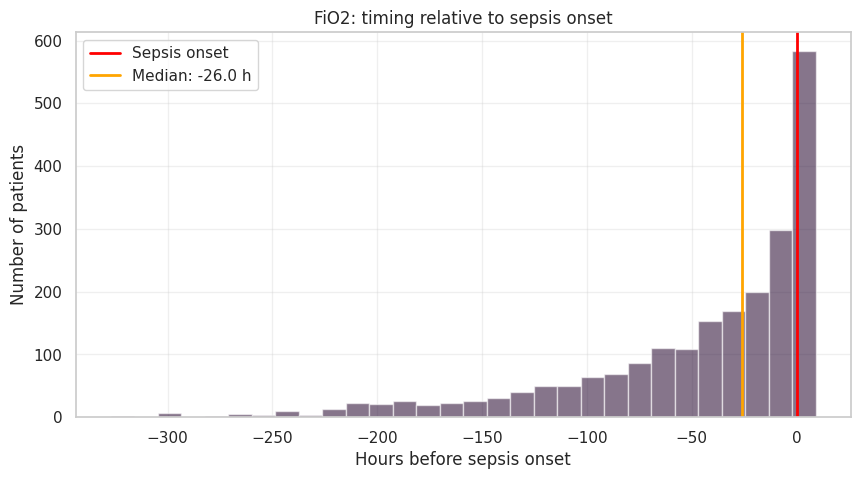

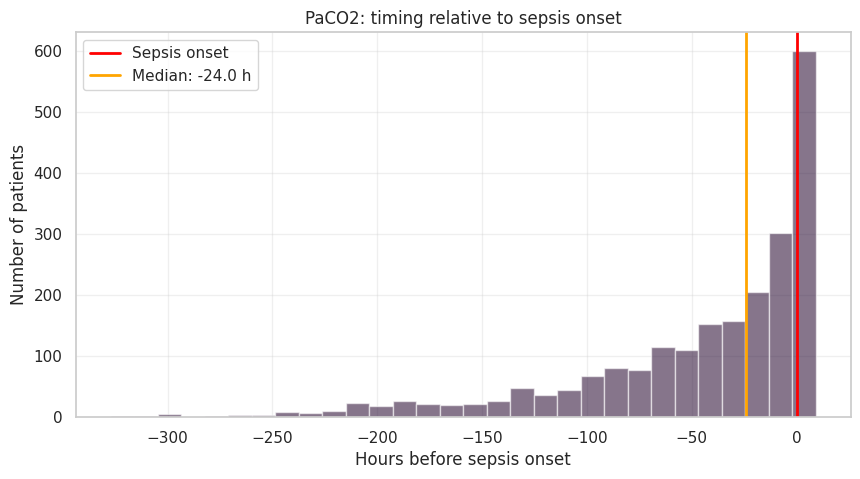

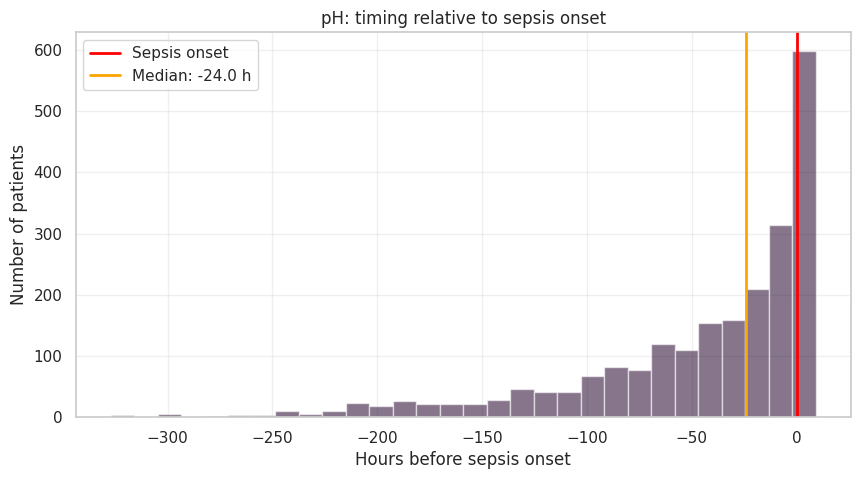

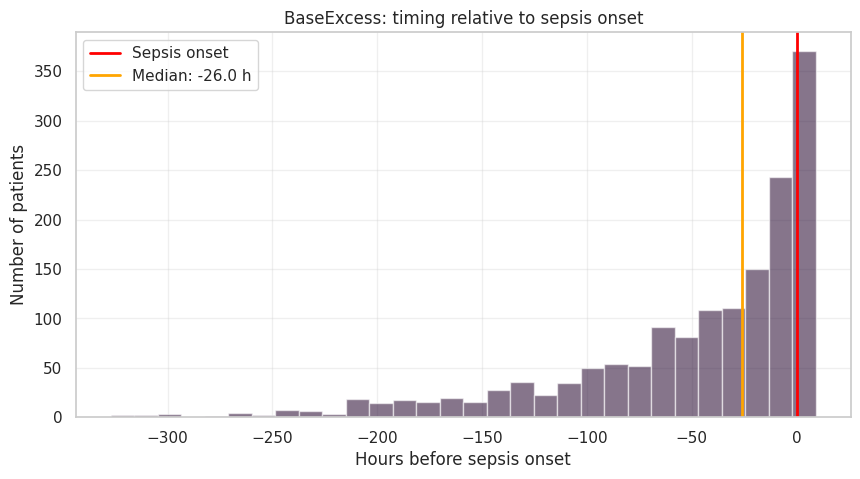

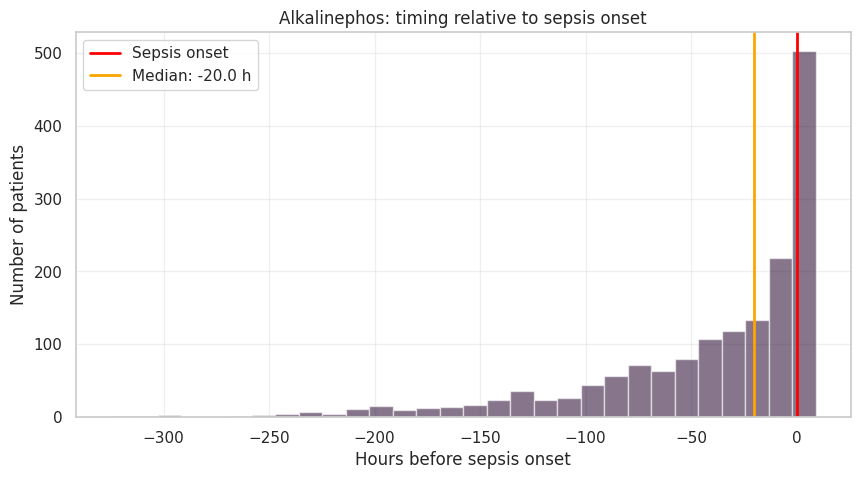

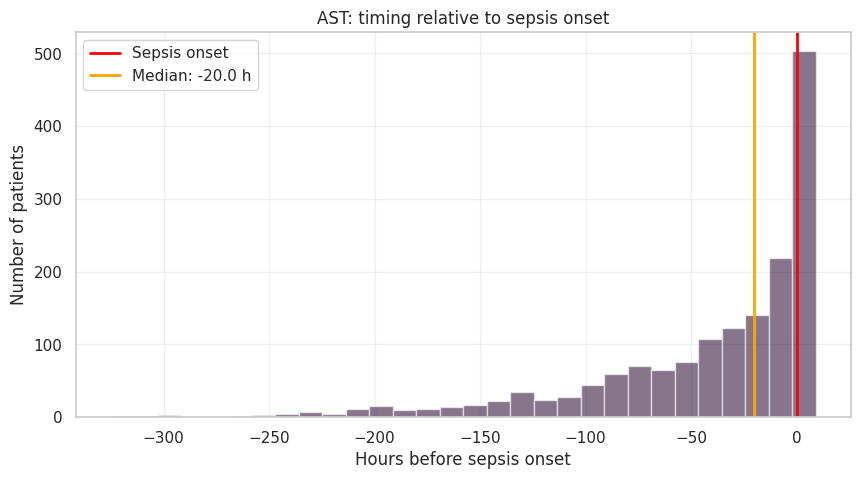

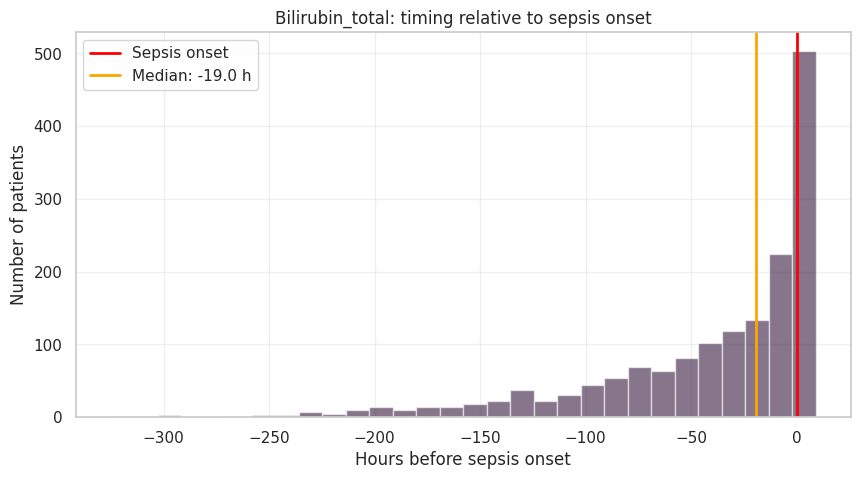

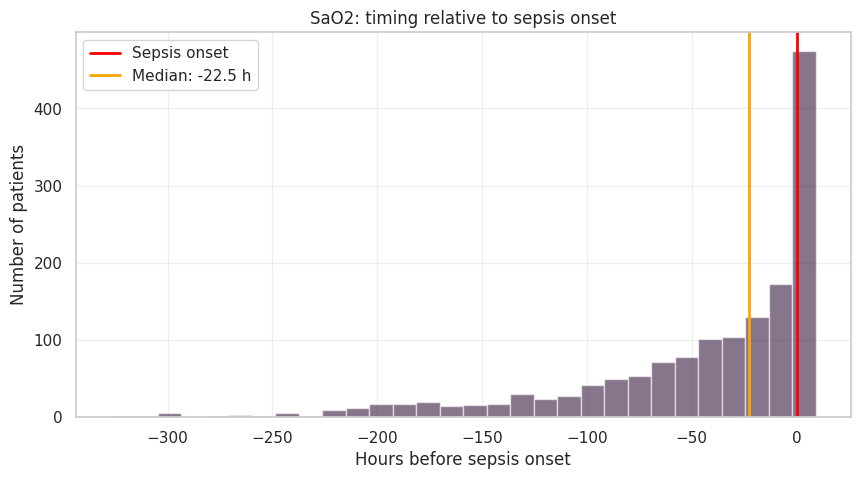

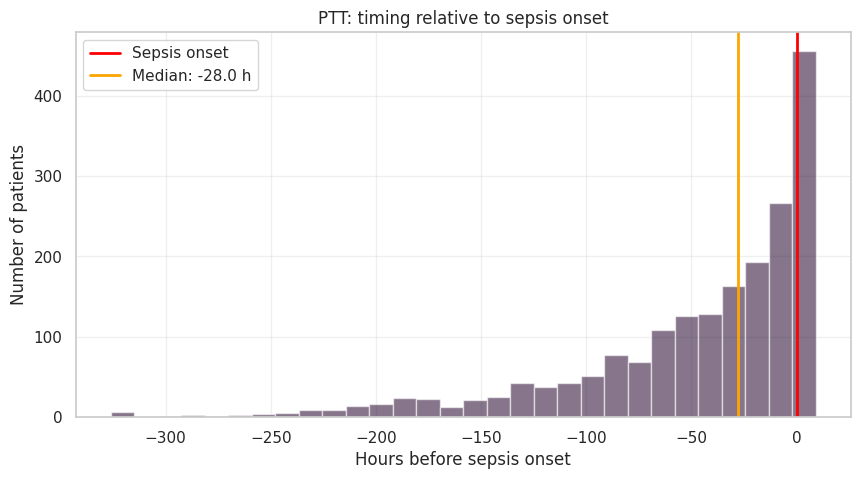

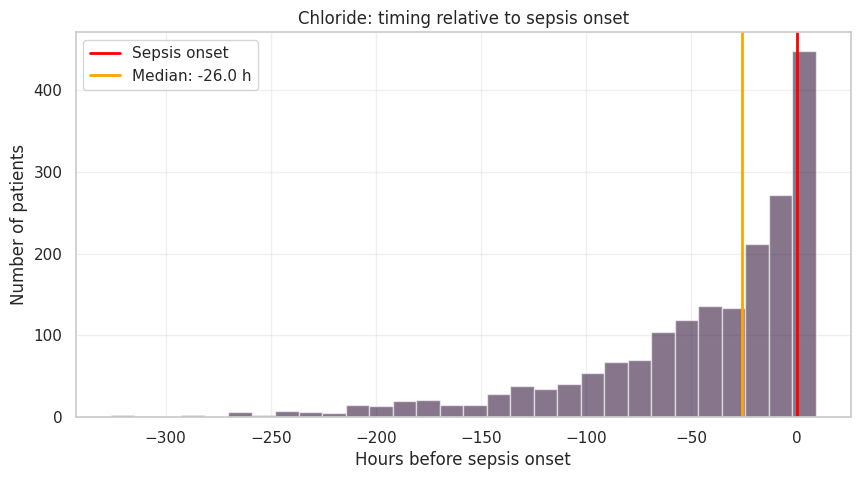

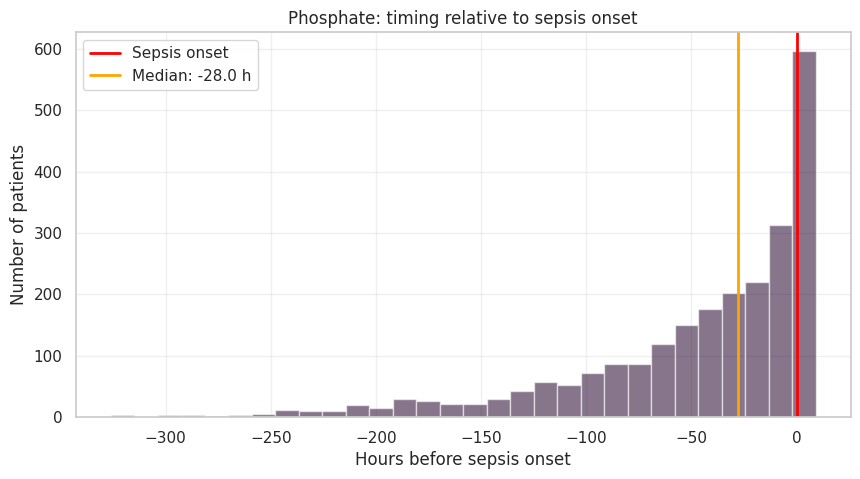

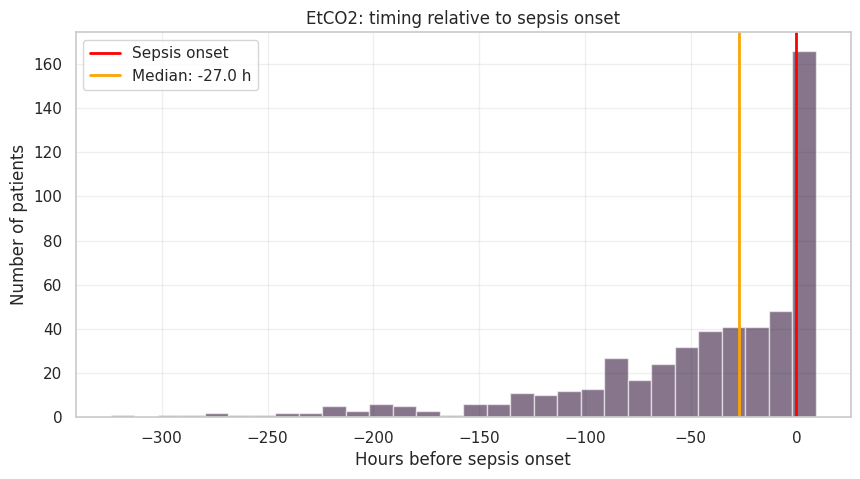

In [39]:
for feature in top_features:
    plt.figure(figsize=(10, 5))

    t_measure = df_septic[df_septic[feature].notna()].groupby('id')['ICULOS'].min()
    relative_time = (t_measure - first_sepsis_time).dropna()

    if not relative_time.empty:
        median_val = relative_time.median()

        plt.hist(relative_time, bins=30, alpha=0.6)
        plt.axvline(0, color='red', linewidth=2, label='Sepsis onset')
        plt.axvline(median_val, color='orange', linewidth=2,
                    label=f'Median: {median_val:.1f} h')

        plt.title(f"{feature}: timing relative to sepsis onset")
        plt.xlabel("Hours before sepsis onset")
        plt.ylabel("Number of patients")
        plt.legend()
        plt.grid(alpha=0.3)

    plt.show()